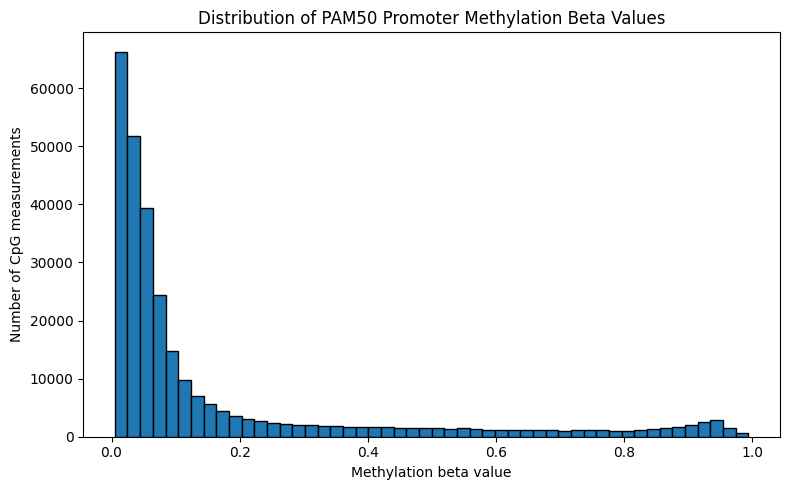

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Path("../results/figures").mkdir(parents=True, exist_ok=True)
Path("../results/tables").mkdir(parents=True, exist_ok=True)

meth = pd.read_csv("../data/processed/meth_pam50.csv", index_col=0)


# overall beta-vals distribtion 
all_beta = meth.to_numpy().ravel()
all_beta = all_beta[~pd.isna(all_beta)]

# Plot the distribution of all observed PAM50 promoter methylation beta values.

plt.figure(figsize=(8, 5))
plt.hist(all_beta, bins=50, edgecolor="black")
plt.xlabel("Methylation beta value")
plt.ylabel("Number of CpG measurements")
plt.title("Distribution of PAM50 Promoter Methylation Beta Values")
plt.tight_layout()

plt.savefig(
    "../results/figures/pam50_promoter_beta_distribution_before_imputation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# Calculate the interquartile range (IQR) for each CpG.
summary = meth.describe().T

summary["iqr"] = meth.quantile(0.75) - meth.quantile(0.25)

summary.to_csv(
    "../results/tables/pam50_promoter_cpg_variation_summary.csv"
)

summary[["mean", "std", "min", "25%", "50%", "75%", "max", "iqr"]].sort_values(
    "iqr"
).head(15)

,mean,std,min,25%,50%,75%,max,iqr
cg14604802,0.011492,0.002086,0.007254,0.010128,0.011180,0.012287,0.024132,0.002159
cg17750334,0.012241,0.024558,0.006799,0.009795,0.010794,0.011959,0.589697,0.002164
cg00459289,0.010638,0.002412,0.007027,0.009255,0.010343,0.011432,0.046686,0.002177
cg10263401,0.011242,0.015445,0.005173,0.009051,0.010134,0.011325,0.279813,0.002274
cg24247425,0.988340,0.032952,0.209319,0.988690,0.990027,0.991067,0.994024,0.002377
cg25152498,0.013342,0.002145,0.009057,0.011878,0.013056,0.014311,0.024089,0.002434
cg05407825,0.010642,0.006145,0.006314,0.008794,0.009982,0.011393,0.138522,0.002598
cg13085338,0.014057,0.008464,0.008763,0.012270,0.013254,0.014910,0.207274,0.002640
cg10379951,0.011783,0.014005,0.006903,0.009685,0.010950,0.012376,0.339832,0.002691
cg27300230,0.012307,0.007411,0.005694,0.010505,0.011804,0.013207,0.179532,0.002702


In [12]:
low_variance_cpgs = summary[summary["iqr"] < 0.02]

print(f"Low-variation CpGs: {len(low_variance_cpgs)} / {meth.shape[1]}")

Low-variation CpGs: 245 / 572


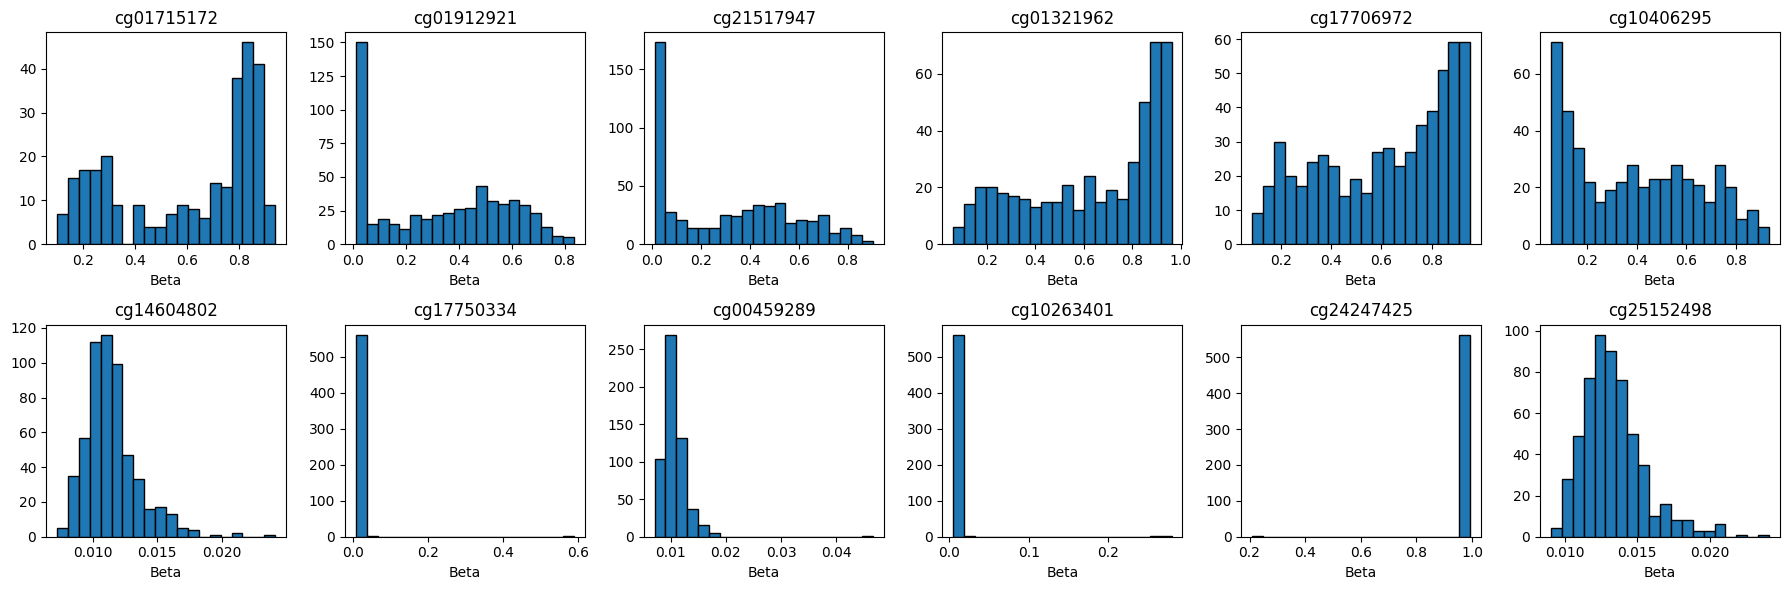

In [13]:
# view high and low variation to understand whether CpGs show meaningful between patient variation
high_var_cpgs = summary.sort_values("iqr", ascending=False).head(6).index
low_var_cpgs = summary.sort_values("iqr").head(6).index

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for ax, cpg in zip(axes[0], high_var_cpgs):
    ax.hist(meth[cpg].dropna(), bins=20, edgecolor="black")
    ax.set_title(cpg)
    ax.set_xlabel("Beta")

for ax, cpg in zip(axes[1], low_var_cpgs):
    ax.hist(meth[cpg].dropna(), bins=20, edgecolor="black")
    ax.set_title(cpg)
    ax.set_xlabel("Beta")

plt.tight_layout()

plt.savefig(
    "../results/figures/high_vs_low_variance_cpg_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()